## setting up

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mean_results import con_means_window, pat_means_window
from rayleigh import phase_dist_window, rayleigh_test, rayleigh_window_group_df

plt.rcdefaults()

GROUPS = ("Control", "Patient")
GROUP_COLORS = {"Control": "#2563eb", "Patient": "#dc2626"}

def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


def _jitter(n, spread=0.025):
    return (np.random.rand(n) - 0.5) * 2 * spread


def _window_long_df():
    con_fix = con_means_window(1, 4, show_plots=False, return_average=False)
    con_cue = con_means_window(4, 7, show_plots=False, return_average=False)
    pat_fix = pat_means_window(1, 4, show_plots=False, return_average=False)
    pat_cue = pat_means_window(4, 7, show_plots=False, return_average=False)

    group_data = {
        "Control": (con_fix, con_cue, "C"),
        "Patient": (pat_fix, pat_cue, "P"),
    }
    rows = []
    metrics = ["rates", "durations", "fixation_rates", "fixation_durations"]
    for metric in metrics:
        for group, (fix_data, cue_data, prefix) in group_data.items():
            for i, (a, b) in enumerate(zip(fix_data[metric], cue_data[metric]), start=1):
                if np.isfinite(a) and np.isfinite(b):
                    rows.append(
                        {
                            "metric": metric,
                            "group": group,
                            "subject": f"{prefix}{i:02d}",
                            "Fixation": float(a),
                            "Cue": float(b),
                        }
                    )
    return pd.DataFrame(rows)


def _group_phase_arrays(group, window, which="start"):

    last = 26 if group == "ctrl" else 18
    phases = []
    for participant in range(1, last + 1):
        p = phase_dist_window(
            participant=participant,
            group=group,
            hemi=0,
            fs=200,
            which=which,
            window=window,
            final=False,
        )
        if p is not None and len(p):
            phases.extend(p)
    return np.asarray(phases)

## figure 1: main group comparisons
- compares controls vs patients across six oculomotor metrics
- faint points are individual participants; larger points are group means
- error bars show sem, so overlap gives a quick visual sense of group separation


/Users/anji/Desktop/lab project/sf_con.py:336: RuntimeWarning: Mean of empty slice
  mean_mean_speed = np.nanmean(agg['mean_speed'])
/Users/anji/Desktop/lab project/sf_con.py:337: RuntimeWarning: Mean of empty slice
  mean_max_speed = np.nanmean(agg['max_speed'])


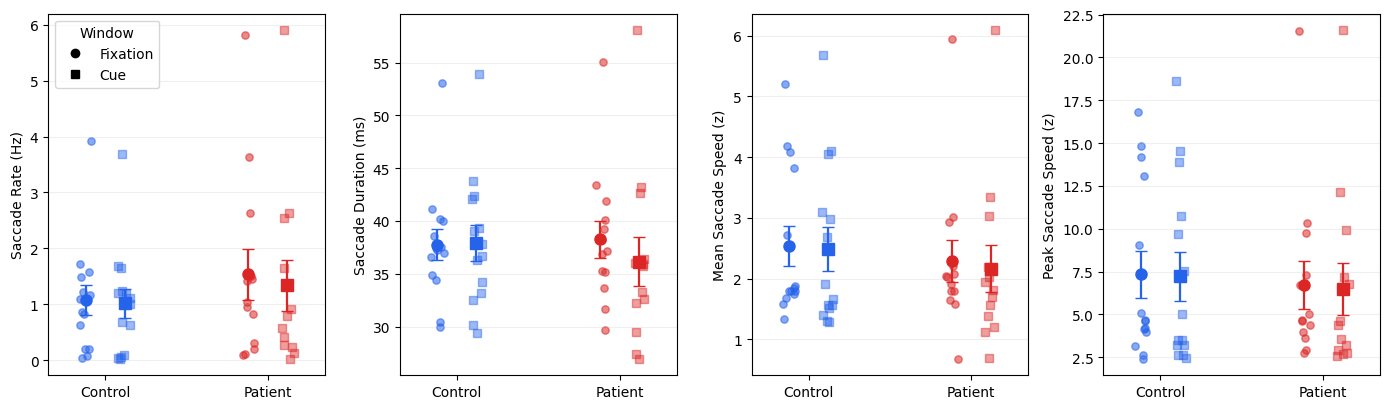

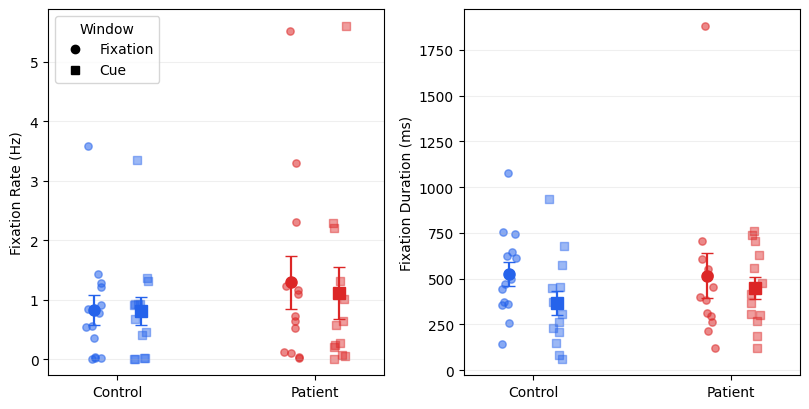

In [2]:
con_fix = con_means_window(1, 4, show_plots=False, return_average=False)
con_cue = con_means_window(4, 7, show_plots=False, return_average=False)
pat_fix = pat_means_window(1, 4, show_plots=False, return_average=False)
pat_cue = pat_means_window(4, 7, show_plots=False, return_average=False)


def _paired_metric_df(metric):
    rows = []
    group_data = {
        "Control": (con_fix, con_cue),
        "Patient": (pat_fix, pat_cue),
    }

    for group, (fix_data, cue_data) in group_data.items():
        fix_map = dict(zip(fix_data["valid_ids"], fix_data[metric]))
        cue_map = dict(zip(cue_data["valid_ids"], cue_data[metric]))
        common = sorted(set(fix_map) & set(cue_map))

        for pid in common:
            fix_val = float(fix_map[pid])
            cue_val = float(cue_map[pid])
            if np.isfinite(fix_val):
                rows.append(
                    {
                        "metric": metric,
                        "group": group,
                        "time": "Fixation",
                        "participant": int(pid),
                        "value": fix_val,
                    }
                )
            if np.isfinite(cue_val):
                rows.append(
                    {
                        "metric": metric,
                        "group": group,
                        "time": "Cue",
                        "participant": int(pid),
                        "value": cue_val,
                    }
                )

    return pd.DataFrame(rows)


def _plot_group_time_panels(metrics, fig_size):
    group_center = {"Control": 0.0, "Patient": 1.0}
    time_offset = {"Fixation": -0.12, "Cue": 0.12}
    marker_map = {"Fixation": "o", "Cue": "s"}
    alpha_map = {"Fixation": 0.55, "Cue": 0.45}

    fig, axes = plt.subplots(1, len(metrics), figsize=fig_size)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel) in zip(axes, metrics):
        mdf = _paired_metric_df(metric)

        for group in ("Control", "Patient"):
            for time_label in ("Fixation", "Cue"):
                xpos = group_center[group] + time_offset[time_label]
                sub = mdf[(mdf["group"] == group) & (mdf["time"] == time_label)]
                vals = sub["value"].to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                if len(vals) == 0:
                    continue

                x = np.full(len(vals), xpos) + _jitter(len(vals), spread=0.04)
                marker = marker_map[time_label]
                alpha = alpha_map[time_label]
                ax.scatter(x, vals, color=GROUP_COLORS[group], alpha=alpha, s=28, marker=marker)

                mu = np.nanmean(vals)
                se = sem(vals)
                ax.errorbar([xpos], [mu], yerr=[se], fmt=marker, color=GROUP_COLORS[group], markersize=8, capsize=4, lw=1.6)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xticks([group_center["Control"], group_center["Patient"]], ["Control", "Patient"])
        ax.set_xlim(-0.35, 1.35)
        ax.grid(alpha=0.2, axis="y")

    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=6, label="Fixation"),
        Line2D([0], [0], marker="s", color="black", linestyle="None", markersize=6, label="Cue"),
    ]
    axes[0].legend(handles=handles, title="Window", loc="best")

    fig.tight_layout()
    return fig


# saccade metrics
saccade_metrics = [
    ("rates", "Saccade Rate (Hz)"),
    ("durations", "Saccade Duration (ms)"),
    ("mean_speeds", "Mean Saccade Speed (z)"),
    ("max_speeds", "Peak Saccade Speed (z)"),
]
fig_1a = _plot_group_time_panels(saccade_metrics, fig_size=(14, 4.2))
plt.show()

# fixation metrics
fixation_metrics = [
    ("fixation_rates", "Fixation Rate (Hz)"),
    ("fixation_durations", "Fixation Duration (ms)"),
]
fig_1b = _plot_group_time_panels(fixation_metrics, fig_size=(8.2, 4.2))
plt.show()

## figure 2: condition effects (fixation vs cue)
- shows within-subject change from fixation (1-4s) to cue (4-7s)
- thin lines are participant trajectories; thick lines are group means with sem
- useful for seeing condition effects and possible group-by-condition interactions


/Users/anji/Desktop/lab project/sf_con.py:336: RuntimeWarning: Mean of empty slice
  mean_mean_speed = np.nanmean(agg['mean_speed'])
/Users/anji/Desktop/lab project/sf_con.py:337: RuntimeWarning: Mean of empty slice
  mean_max_speed = np.nanmean(agg['max_speed'])


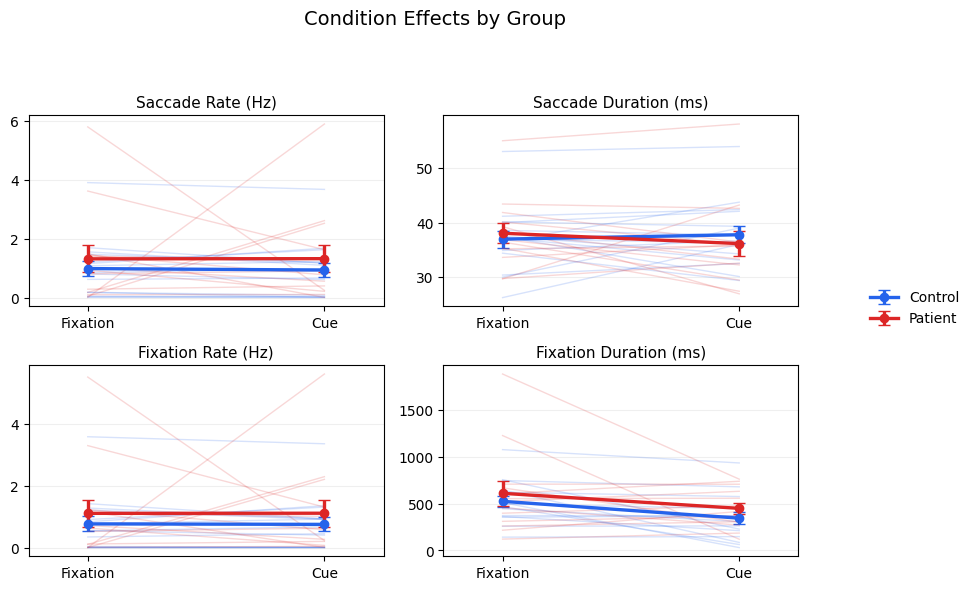

In [3]:
df = _window_long_df()
specs = [
    ("rates", "Saccade Rate (Hz)"),
    ("durations", "Saccade Duration (ms)"),
    ("fixation_rates", "Fixation Rate (Hz)"),
    ("fixation_durations", "Fixation Duration (ms)"),
]
x = np.array([0.0, 0.16])

fig, axes = plt.subplots(2, 2, figsize=(8.8, 6.1))
for ax, (metric, label) in zip(axes.ravel(), specs):
    sub = df[df["metric"] == metric]
    for group in GROUPS:
        g = sub[sub["group"] == group]
        for _, row in g.iterrows():
            y = np.array([row["Fixation"], row["Cue"]], dtype=float)
            ax.plot(x, y, color=GROUP_COLORS[group], alpha=0.18, lw=1.0)
        means = np.array([g["Fixation"].mean(), g["Cue"].mean()])
        errs = np.array([sem(g["Fixation"]), sem(g["Cue"])])
        ax.errorbar(x, means, yerr=errs, color=GROUP_COLORS[group], lw=2.4, marker="o", capsize=4, label=group)

    ax.set_xticks(x, ["Fixation", "Cue"])
    ax.set_xlim(-0.04, 0.20)
    ax.set_title(label, fontsize=11)
    ax.grid(alpha=0.2, axis="y")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc="center left", bbox_to_anchor=(0.98, 0.49), frameon=False)
fig.suptitle("Condition Effects by Group", fontsize=14)
fig.tight_layout(rect=[0, 0.02, 0.93, 0.92])
plt.show()


## figure 3: saccade-onset phase distributions
- polar histograms of phase at saccade onset for each group/window
- bar height is proportion per phase bin; arrows show mean resultant direction
- `r` indicates clustering strength and `p` tests deviation from a uniform phase distribution


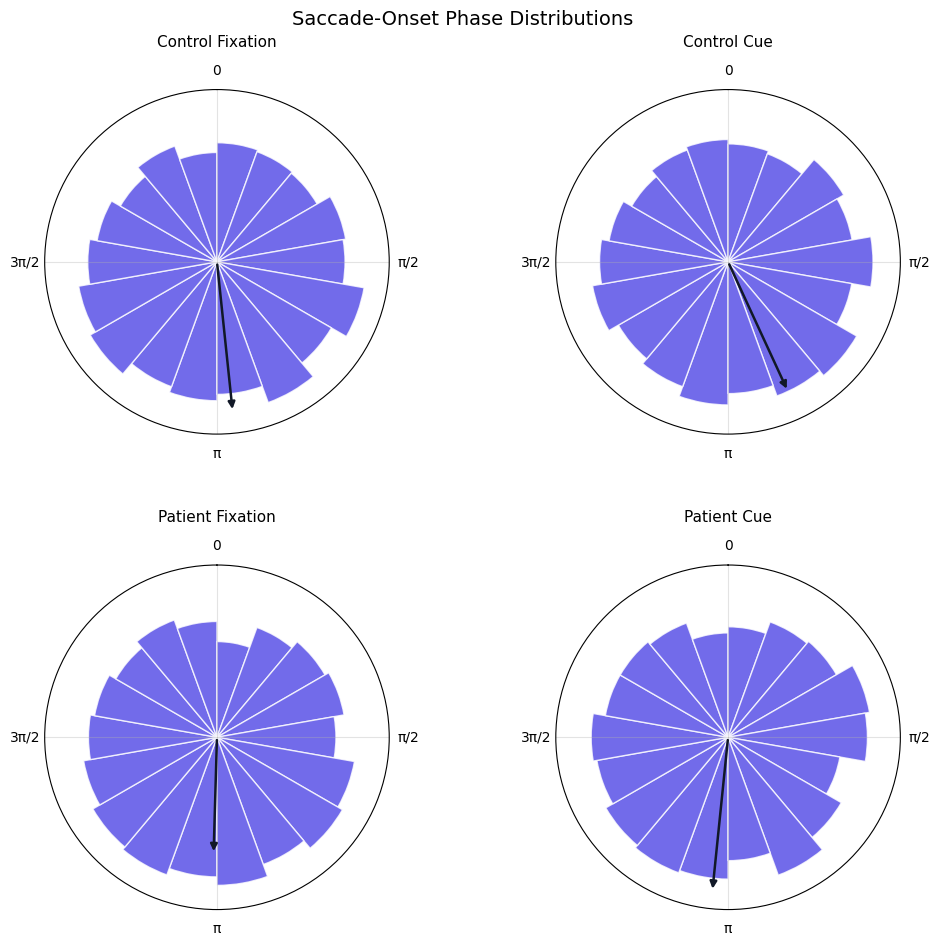

In [4]:
windows = [(1, 4), (4, 7)]
phase_map = {
    ("Control", "Fixation"): _group_phase_arrays("ctrl", windows[0], which="start"),
    ("Control", "Cue"): _group_phase_arrays("ctrl", windows[1], which="start"),
    ("Patient", "Fixation"): _group_phase_arrays("patient", windows[0], which="start"),
    ("Patient", "Cue"): _group_phase_arrays("patient", windows[1], which="start"),
}
manual_r_map = {
    ("Control", "Fixation"): 0.146,
    ("Control", "Cue"): 0.138,
    ("Patient", "Fixation"): 0.113,
    ("Patient", "Cue"): 0.150,
}

fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(10, 10))
keys = [("Control", "Fixation"), ("Control", "Cue"), ("Patient", "Fixation"), ("Patient", "Cue")]
bins = np.linspace(-np.pi, np.pi, 19)
panel_data = {}

for key in keys:
    phases = phase_map[key]
    phases = phases[np.isfinite(phases)]
    if len(phases):
        counts, edges = np.histogram(phases, bins=bins)
        prop = counts / len(phases)
        centers = (edges[:-1] + edges[1:]) / 2
        width = edges[1] - edges[0]
        r_event = np.abs(np.mean(np.exp(1j * phases)))
        mean_dir = np.angle(np.mean(np.exp(1j * phases)))
        _, pval = rayleigh_test(phases)
        r_arrow = manual_r_map[key]
        panel_data[key] = {
            "prop": prop,
            "centers": centers,
            "width": width,
            "r_event": r_event,
            "r_arrow": r_arrow,
            "mean_dir": mean_dir,
            "p": pval,
            "n": len(phases),
        }
    else:
        panel_data[key] = None

max_prop = max((d["prop"].max() for d in panel_data.values() if d is not None), default=0.1)
r_lim = max_prop * 1.15
max_r_arrow = max((d["r_arrow"] for d in panel_data.values() if d is not None and np.isfinite(d["r_arrow"])), default=1.0)

for ax, key in zip(axes.ravel(), keys):
    d = panel_data[key]
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetagrids([0, 90, 180, 270], labels=["0", "π/2", "π", "3π/2"])
    ax.set_ylim(0, r_lim)
    ax.set_yticks([])
    ax.grid(alpha=0.35)
    ax.bar(d["centers"], d["prop"], width=d["width"], color="#4f46e5", alpha=0.8, edgecolor="white")

    arrow_len = (d["r_arrow"] / max(1e-12, max_r_arrow)) * (0.9 * r_lim)
    ax.annotate("", xy=(d["mean_dir"], arrow_len), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#111827"))

    ax.set_title(f"{key[0]} {key[1]}", fontsize=11, pad=12)

fig.suptitle("Saccade-Onset Phase Distributions", fontsize=14)
fig.subplots_adjust(left=0.05, right=0.97, bottom=0.08, top=0.90, wspace=0.25, hspace=0.38)
plt.show()



## fixation-onset phase locking

In [ ]:
windows = [(1, 4), (4, 7)]
phase_map = {
    ("Control", "Fixation"): _group_phase_arrays("ctrl", windows[0], which="end"),
    ("Control", "Cue"): _group_phase_arrays("ctrl", windows[1], which="end"),
    ("Patient", "Fixation"): _group_phase_arrays("patient", windows[0], which="end"),
    ("Patient", "Cue"): _group_phase_arrays("patient", windows[1], which="end"),
}
manual_r_map = {
    ("Control", "Fixation"): 0.157,
    ("Control", "Cue"): 0.144,
    ("Patient", "Fixation"): 0.120,
    ("Patient", "Cue"): 0.157,
}

fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(10, 10))
keys = [("Control", "Fixation"), ("Control", "Cue"), ("Patient", "Fixation"), ("Patient", "Cue")]
bins = np.linspace(-np.pi, np.pi, 19)
panel_data = {}

for key in keys:
    phases = phase_map[key]
    phases = phases[np.isfinite(phases)]
    if len(phases):
        counts, edges = np.histogram(phases, bins=bins)
        prop = counts / len(phases)
        centers = (edges[:-1] + edges[1:]) / 2
        width = edges[1] - edges[0]
        r_event = np.abs(np.mean(np.exp(1j * phases)))
        mean_dir = np.angle(np.mean(np.exp(1j * phases)))
        _, pval = rayleigh_test(phases)
        r_arrow = manual_r_map[key]
        panel_data[key] = {
            "prop": prop,
            "centers": centers,
            "width": width,
            "r_event": r_event,
            "r_arrow": r_arrow,
            "mean_dir": mean_dir,
            "p": pval,
            "n": len(phases),
        }
    else:
        panel_data[key] = None

max_prop = max((d["prop"].max() for d in panel_data.values() if d is not None), default=0.1)
r_lim = max_prop * 1.15
max_r_arrow = max((d["r_arrow"] for d in panel_data.values() if d is not None and np.isfinite(d["r_arrow"])), default=1.0)

for ax, key in zip(axes.ravel(), keys):
    d = panel_data[key]
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetagrids([0, 90, 180, 270], labels=["0", "π/2", "π", "3π/2"])
    ax.set_ylim(0, r_lim)
    ax.set_yticks([])
    ax.grid(alpha=0.35)
    ax.bar(d["centers"], d["prop"], width=d["width"], color="#4f46e5", alpha=0.8, edgecolor="white")

    arrow_len = (d["r_arrow"] / max(1e-12, max_r_arrow)) * (0.9 * r_lim)
    ax.annotate("", xy=(d["mean_dir"], arrow_len), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#111827"))

    ax.set_title(f"{key[0]} {key[1]}", fontsize=11, pad=12)

fig.suptitle("Fixation-Onset Phase Distributions", fontsize=14)
fig.subplots_adjust(left=0.05, right=0.97, bottom=0.08, top=0.90, wspace=0.25, hspace=0.38)
plt.show()

